In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point
import matplotlib.patches as patches
import datetime
import numpy as np

## Map representation

neighborhood
Oasis         27
La Quinina    14
Name: count, dtype: int64
Non-residential inside neighborhoods: 0


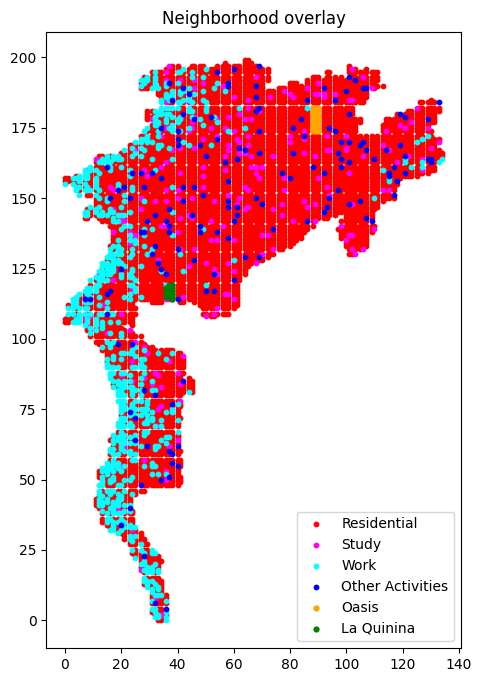

In [2]:
# Background: all typed cells
locs = pd.read_csv("locations.csv")  # columns: Category,X,Y

# Neighborhood tags
neigh = pd.read_csv("neighborhood_cells.csv")  # columns: neighborhood,x,y

# 1) Check counts
print(neigh["neighborhood"].value_counts())

# 2) Verify all neighborhood cells are Residential
merged = neigh.merge(locs, left_on=["x","y"], right_on=["X","Y"], how="left")
bad = merged[merged["Category"] != "Residential"]
print("Non-residential inside neighborhoods:", len(bad))

# 3) Plot overlay
color_map = {"Residential":"red","Study":"magenta","Work":"cyan","Other Activities":"blue"}
plt.figure(figsize=(8,8))
for cat,col in color_map.items():
    sub = locs[locs["Category"] == cat]
    plt.scatter(sub["X"], sub["Y"], s=10, c=col, label=cat)

neigh_colors = {"Oasis":"orange", "La Quinina":"green"}
for name,col in neigh_colors.items():
    sub = neigh[neigh["neighborhood"] == name]
    plt.scatter(sub["x"], sub["y"], s=12, c=col, label=name)

plt.legend()
plt.gca().set_aspect("equal","box")
plt.title("Neighborhood overlay")
plt.show()

## Results

Saved figures: sei_counts.png, new_cases.png, prevalence.png, stacked_props.png


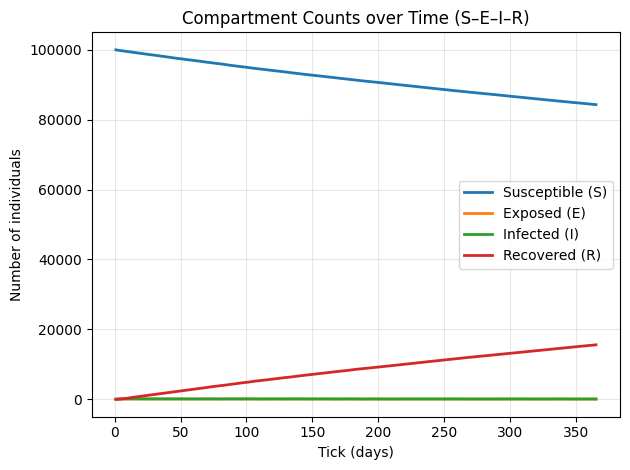

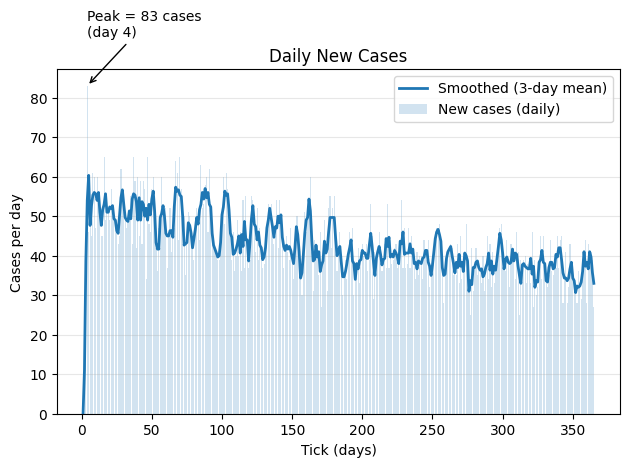

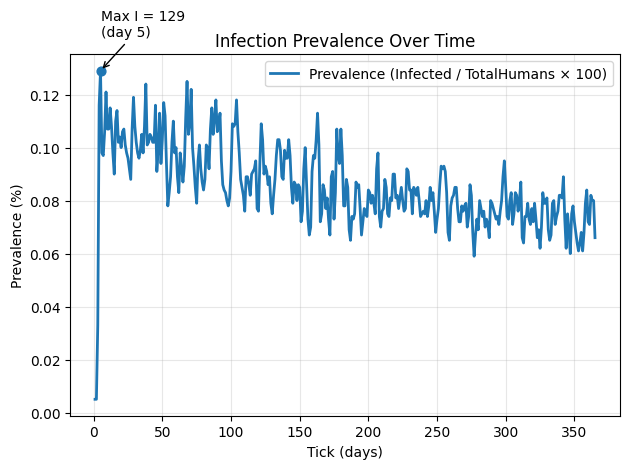

In [12]:
df = pd.read_csv("results_100k.csv")

# Standardize column access (in case of stray spaces or mixed case)
df.columns = [c.strip() for c in df.columns]

# Basic derived metrics
df["Prevalence_%"] = 100.0 * df["Infected"] / df["TotalHumans"]

# A light smoothing for incidence (3-day centered window by default where possible)
# For very short series this reverts to available points without extrapolation.
if len(df) >= 3:
    df["NewCases_smooth"] = df["New Cases per day"].rolling(window=3, center=True, min_periods=1).mean()
else:
    df["NewCases_smooth"] = df["New Cases per day"].astype(float)

# Locate peaks for clear annotation
peak_I_idx = int(df["Infected"].idxmax())
peak_I_tick = int(df.loc[peak_I_idx, "tick"])
peak_I_val = int(df.loc[peak_I_idx, "Infected"])

peak_NC_idx = int(df["New Cases per day"].idxmax())
peak_NC_tick = int(df.loc[peak_NC_idx, "tick"])
peak_NC_val = int(df.loc[peak_NC_idx, "New Cases per day"])

# -----------------------------
# 2) Figure: S–E–I–R counts
# -----------------------------
plt.figure()
plt.plot(df["tick"], df["Susceptible"], label="Susceptible (S)", linewidth=2)
plt.plot(df["tick"], df["Exposed"],     label="Exposed (E)",     linewidth=2)
plt.plot(df["tick"], df["Infected"],    label="Infected (I)",    linewidth=2)
plt.plot(df["tick"], df["Recovered"],   label="Recovered (R)",   linewidth=2)
plt.title("Compartment Counts over Time (S–E–I–R)")
plt.xlabel("Tick (days)")
plt.ylabel("Number of individuals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sei_counts.png", dpi=300)

# -----------------------------
# 3) Figure: New cases per day
# -----------------------------
plt.figure()
# Bars for raw daily new cases
plt.bar(df["tick"], df["New Cases per day"], width=0.8, alpha=0.2, label="New cases (daily)")
# Smoothed overlay for trend visibility
plt.plot(df["tick"], df["NewCases_smooth"], linewidth=2, label="Smoothed (3-day mean)")
# Annotate the peak
plt.annotate(f"Peak = {peak_NC_val} cases\n(day {peak_NC_tick})",
             xy=(peak_NC_tick, peak_NC_val),
             xytext=(peak_NC_tick, peak_NC_val * 1.15 if peak_NC_val > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.title("Daily New Cases")
plt.xlabel("Tick (days)")
plt.ylabel("Cases per day")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("new_cases.png", dpi=300)

# -----------------------------
# 4) Figure: Infection prevalence
# -----------------------------
plt.figure()
plt.plot(df["tick"], df["Prevalence_%"], linewidth=2, label="Prevalence (Infected / TotalHumans × 100)")
plt.title("Infection Prevalence Over Time")
plt.xlabel("Tick (days)")
plt.ylabel("Prevalence (%)")
plt.grid(True, alpha=0.3)
# Mark and annotate the peak
plt.scatter([peak_I_tick], [100.0 * peak_I_val / df.loc[peak_I_idx, "TotalHumans"]], s=40)
plt.annotate(f"Max I = {peak_I_val}\n(day {peak_I_tick})",
             xy=(peak_I_tick, 100.0 * peak_I_val / df.loc[peak_I_idx, "TotalHumans"]),
             xytext=(peak_I_tick, max(df["Prevalence_%"]) * 1.1 if max(df["Prevalence_%"]) > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.legend()
plt.tight_layout()
plt.savefig("prevalence.png", dpi=300)

# -----------------------------
# 5) Figure: Stacked proportions
# -----------------------------
# Convert to proportions to visualize composition dynamics
total = df[["Susceptible", "Exposed", "Infected", "Recovered"]].sum(axis=1)
props = pd.DataFrame({
    "tick": df["tick"],
    "S": df["Susceptible"] / total,
    "E": df["Exposed"]     / total,
    "I": df["Infected"]    / total,
    "R": df["Recovered"]   / total
})


print("Saved figures: sei_counts.png, new_cases.png, prevalence.png, stacked_props.png")


## Resultados para los dos barrios

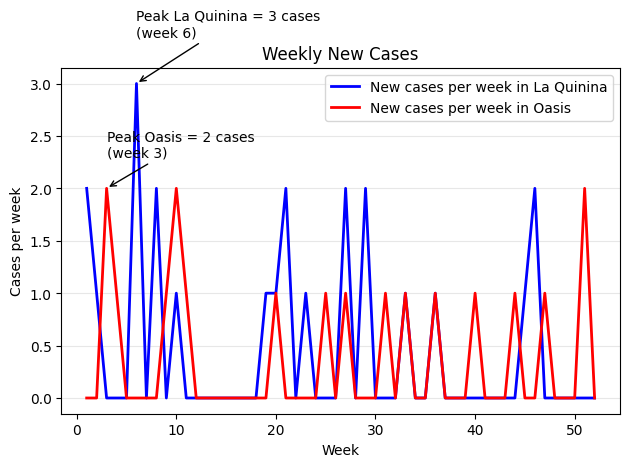

In [15]:
df_neighborhoods = pd.read_csv("weekly_neighborhood_cases.csv")


peak_NC_idx_oasis = int(df_neighborhoods["new_cases_oasis"].idxmax())
peak_NC_tick_oasis = int(df_neighborhoods.loc[peak_NC_idx_oasis, "week"])
peak_NC_val_oasis = int(df_neighborhoods.loc[peak_NC_idx_oasis, "new_cases_oasis"])

peak_NC_idx_quinina = int(df_neighborhoods["new_cases_laquinina"].idxmax())
peak_NC_tick_quinina = int(df_neighborhoods.loc[peak_NC_idx_quinina, "week"])
peak_NC_val_quinina = int(df_neighborhoods.loc[peak_NC_idx_quinina, "new_cases_laquinina"])

plt.figure()

# Smoothed overlay for trend visibility
plt.plot(df_neighborhoods["week"], df_neighborhoods["new_cases_laquinina"], linewidth=2, label="New cases per week in La Quinina", color="blue")
plt.plot(df_neighborhoods["week"], df_neighborhoods["new_cases_oasis"], linewidth=2, label="New cases per week in Oasis", color="red")
# Annotate the peak
plt.annotate(f"Peak Oasis = {peak_NC_val_oasis} cases\n(week {peak_NC_tick_oasis})",
             xy=(peak_NC_tick_oasis, peak_NC_val_oasis),
             xytext=(peak_NC_tick_oasis, peak_NC_val_oasis * 1.15 if peak_NC_val_oasis > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.annotate(f"Peak La Quinina = {peak_NC_val_quinina} cases\n(week {peak_NC_tick_quinina})",
             xy=(peak_NC_tick_quinina, peak_NC_val_quinina),
             xytext=(peak_NC_tick_quinina, peak_NC_val_quinina * 1.15 if peak_NC_val_quinina > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))

plt.title("Weekly New Cases")
plt.xlabel("Week")
plt.ylabel("Cases per week")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("new_cases_neighborhoods.png", dpi=300)





=== INCIDENCE RATE SUMMARY (per 1000 people per week) ===

Oasis:
  Mean:   0.66
  Median: 0.00
  Max:    3.81
  Total new cases: 18

La Quinina:
  Mean:   1.96
  Median: 0.00
  Max:    13.27
  Total new cases: 23


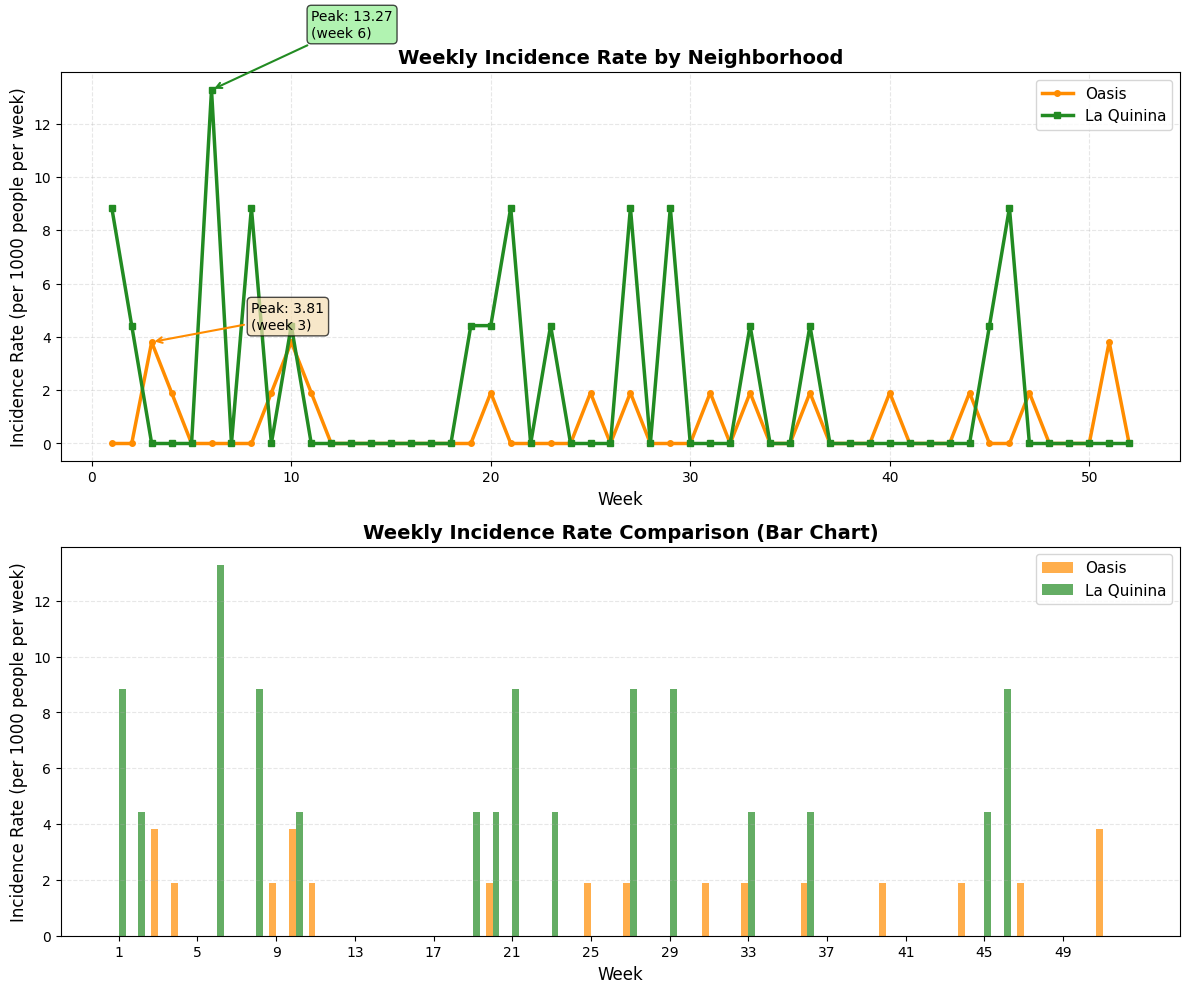


✓ Saved figure: incidence_rate_neighborhoods.png


In [14]:
# Calculate Incidence Rates for both neighborhoods
# Incidence Rate = (New Cases / Population at Risk) × 1000 (per 1000 people per week)
df_neighborhoods = pd.read_csv("weekly_neighborhood_cases.csv")
df_neighborhoods["incidence_rate_oasis"] = (
    df_neighborhoods["new_cases_oasis"] / df_neighborhoods["total_humans_oasis"]
) * 1000

df_neighborhoods["incidence_rate_laquinina"] = (
    df_neighborhoods["new_cases_laquinina"] / df_neighborhoods["total_humans_laquinina"]
) * 1000

# Summary statistics
print("=== INCIDENCE RATE SUMMARY (per 1000 people per week) ===\n")
print(f"Oasis:")
print(f"  Mean:   {df_neighborhoods['incidence_rate_oasis'].mean():.2f}")
print(f"  Median: {df_neighborhoods['incidence_rate_oasis'].median():.2f}")
print(f"  Max:    {df_neighborhoods['incidence_rate_oasis'].max():.2f}")
print(f"  Total new cases: {df_neighborhoods['new_cases_oasis'].sum()}")

print(f"\nLa Quinina:")
print(f"  Mean:   {df_neighborhoods['incidence_rate_laquinina'].mean():.2f}")
print(f"  Median: {df_neighborhoods['incidence_rate_laquinina'].median():.2f}")
print(f"  Max:    {df_neighborhoods['incidence_rate_laquinina'].max():.2f}")
print(f"  Total new cases: {df_neighborhoods['new_cases_laquinina'].sum()}")

# Find peaks
peak_IR_oasis_idx = df_neighborhoods["incidence_rate_oasis"].idxmax()
peak_IR_oasis_week = df_neighborhoods.loc[peak_IR_oasis_idx, "week"]
peak_IR_oasis_val = df_neighborhoods.loc[peak_IR_oasis_idx, "incidence_rate_oasis"]

peak_IR_quinina_idx = df_neighborhoods["incidence_rate_laquinina"].idxmax()
peak_IR_quinina_week = df_neighborhoods.loc[peak_IR_quinina_idx, "week"]
peak_IR_quinina_val = df_neighborhoods.loc[peak_IR_quinina_idx, "incidence_rate_laquinina"]

# Plot Incidence Rates
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Line plot with both neighborhoods
ax1.plot(df_neighborhoods["week"], df_neighborhoods["incidence_rate_oasis"], 
         linewidth=2.5, label="Oasis", color="darkorange", marker='o', markersize=4)
ax1.plot(df_neighborhoods["week"], df_neighborhoods["incidence_rate_laquinina"], 
         linewidth=2.5, label="La Quinina", color="forestgreen", marker='s', markersize=4)

# Annotate peaks
ax1.annotate(f"Peak: {peak_IR_oasis_val:.2f}\n(week {int(peak_IR_oasis_week)})",
             xy=(peak_IR_oasis_week, peak_IR_oasis_val),
             xytext=(peak_IR_oasis_week + 5, peak_IR_oasis_val + 0.5),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="darkorange"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.7))

ax1.annotate(f"Peak: {peak_IR_quinina_val:.2f}\n(week {int(peak_IR_quinina_week)})",
             xy=(peak_IR_quinina_week, peak_IR_quinina_val),
             xytext=(peak_IR_quinina_week + 5, peak_IR_quinina_val + 2),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="forestgreen"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

ax1.set_title("Weekly Incidence Rate by Neighborhood", fontsize=14, fontweight='bold')
ax1.set_xlabel("Week", fontsize=12)
ax1.set_ylabel("Incidence Rate (per 1000 people per week)", fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='upper right')

# Bottom plot: Bar chart comparison
x = np.arange(len(df_neighborhoods))
width = 0.35

bars1 = ax2.bar(x - width/2, df_neighborhoods["incidence_rate_oasis"], 
                width, label="Oasis", color="darkorange", alpha=0.7)
bars2 = ax2.bar(x + width/2, df_neighborhoods["incidence_rate_laquinina"], 
                width, label="La Quinina", color="forestgreen", alpha=0.7)

ax2.set_title("Weekly Incidence Rate Comparison (Bar Chart)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Week", fontsize=12)
ax2.set_ylabel("Incidence Rate (per 1000 people per week)", fontsize=12)
ax2.set_xticks(x[::4])  # Show every 4th week to avoid crowding
ax2.set_xticklabels(df_neighborhoods["week"][::4].astype(int))
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("incidence_rate_neighborhoods.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved figure: incidence_rate_neighborhoods.png")


## Understanding Incidence Rate vs. Prevalence Rate

### **Incidence Rate**
- **Definition:** Measures the rate of **NEW cases** occurring in a population over a specific time period
- **Formula:** `(Number of new cases / Population at risk) × multiplier (e.g., 1000)`
- **Unit:** Cases per 1000 people per week (or per day, month, year)
- **Question answered:** "How fast is the disease spreading?"
- **Use case:** Tracking disease transmission dynamics, identifying outbreaks, evaluating intervention effectiveness
- **Example:** If 5 new dengue cases occur in a neighborhood of 500 people in one week:
  - Incidence rate = (5 / 500) × 1000 = **10 cases per 1000 people per week**

### **Prevalence Rate**
- **Definition:** Measures the **TOTAL proportion** of cases that exist in a population at a specific point in time
- **Formula:** `(Number of existing cases / Total population) × 100`
- **Unit:** Percentage (%)
- **Question answered:** "How much disease burden exists right now?"
- **Use case:** Assessing disease burden, healthcare resource planning
- **Example:** If 50 people currently have dengue in a neighborhood of 500 people:
  - Prevalence = (50 / 500) × 100 = **10% prevalence**

### **Key Differences**

| Aspect | Incidence Rate | Prevalence Rate |
|--------|----------------|-----------------|
| **What it counts** | New cases only | All existing cases |
| **Time dimension** | Rate over period (dynamic) | Snapshot in time (static) |
| **Disease stage** | New infections | Current infections |
| **Best for** | Outbreak detection, transmission tracking | Disease burden assessment |
| **Sensitive to** | Changes in transmission | Disease duration & transmission |

### **For Dengue Surveillance:**
**Incidence rate is more informative** because:
1. Shows real-time transmission dynamics
2. Detects outbreaks early (rapid increase in incidence)
3. Evaluates intervention impact (decrease in incidence)
4. Accounts for population differences between neighborhoods

In our simulation, we track **weekly incidence rates** for Oasis and La Quinina neighborhoods to compare dengue transmission patterns between areas with different population sizes.


## Results after modifications